### Library

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import RobustScaler

In [13]:
df = pd.read_csv("Housing_Price_Data.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Check the Summary of The Dataset

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


##### Manual Mapping

In [15]:
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, "semi-furnished": 0,'unfurnished': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})
df["hotwaterheating"] = df["hotwaterheating"].map({'yes': 1, 'no': 0})
df["airconditioning"] = df["airconditioning"].map({'yes': 1, 'no': 0})

#### Distribution of Price

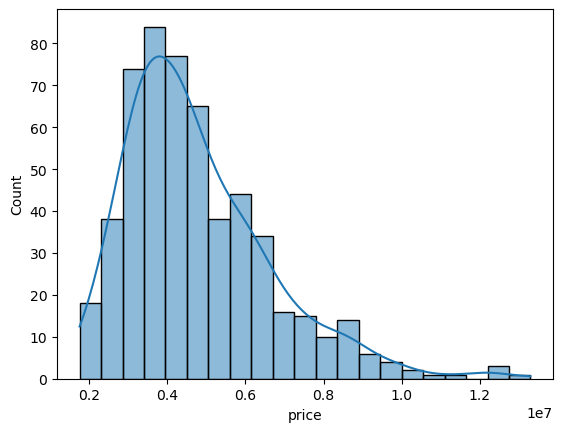

In [16]:
sns.histplot(df['price'], kde=True)
plt.show()

#### Average House Price by Furnishing Status

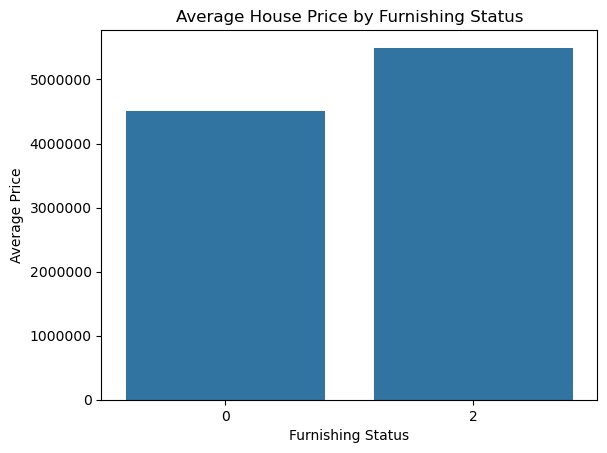

In [17]:
avg_price_by_furnishing = df.groupby('furnishingstatus')['price'].mean()
sns.barplot(x=avg_price_by_furnishing.index, y=avg_price_by_furnishing.values)
plt.title('Average House Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Outlier Check

In [18]:
df["mainroad"].unique()

array([1, 0], dtype=int64)

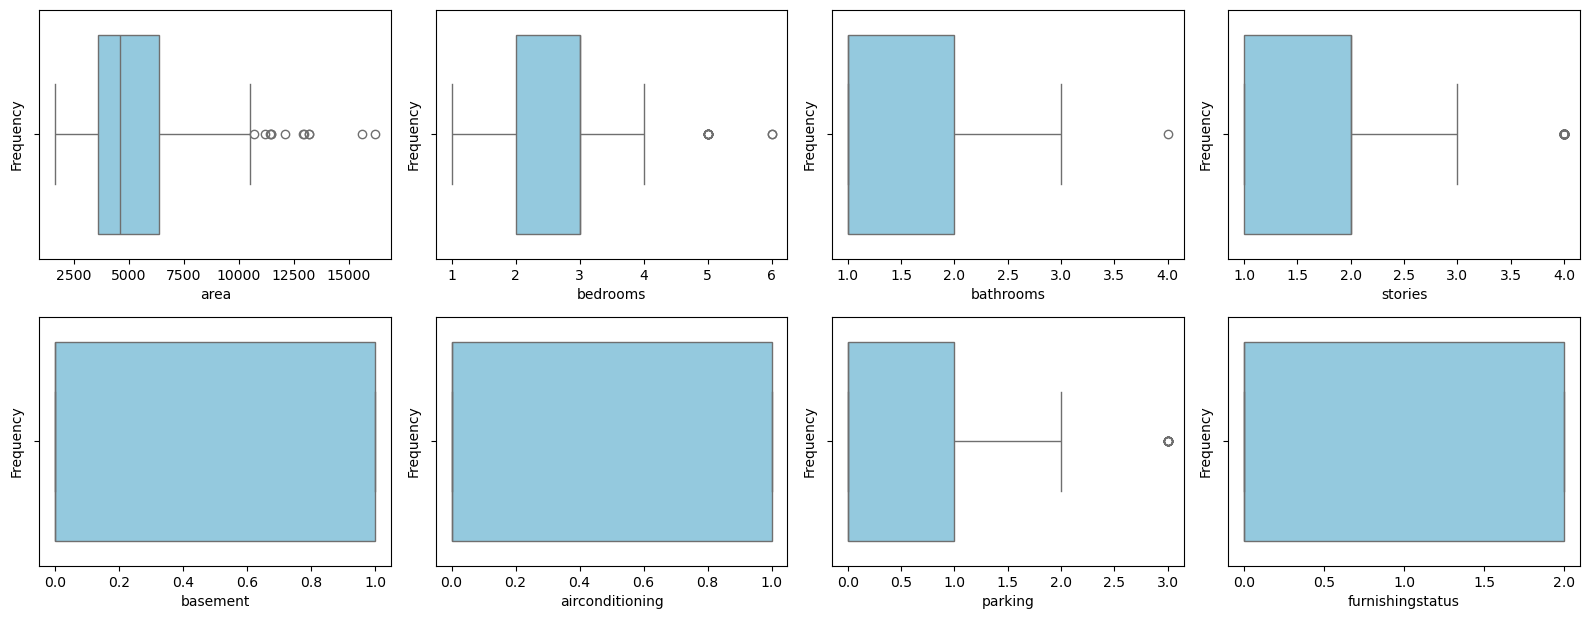

In [19]:
Numerical = df.drop(["price", "mainroad", "guestroom", "hotwaterheating", "prefarea"], axis= 1)

plt.figure(figsize=(16, 12))

for i, col in enumerate(Numerical, 1):
    plt.subplot(4, 4, i) 
    sns.boxplot(x=df[col], color='skyblue')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()

plt.show()

### Feature Engineering

In [20]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"] + df["guestroom"]
df["is_lux"] = (df["airconditioning"] != 0) & (df["prefarea"] != 0)
df["is_lux"] = df["is_lux"].astype(int)

### Heatmap

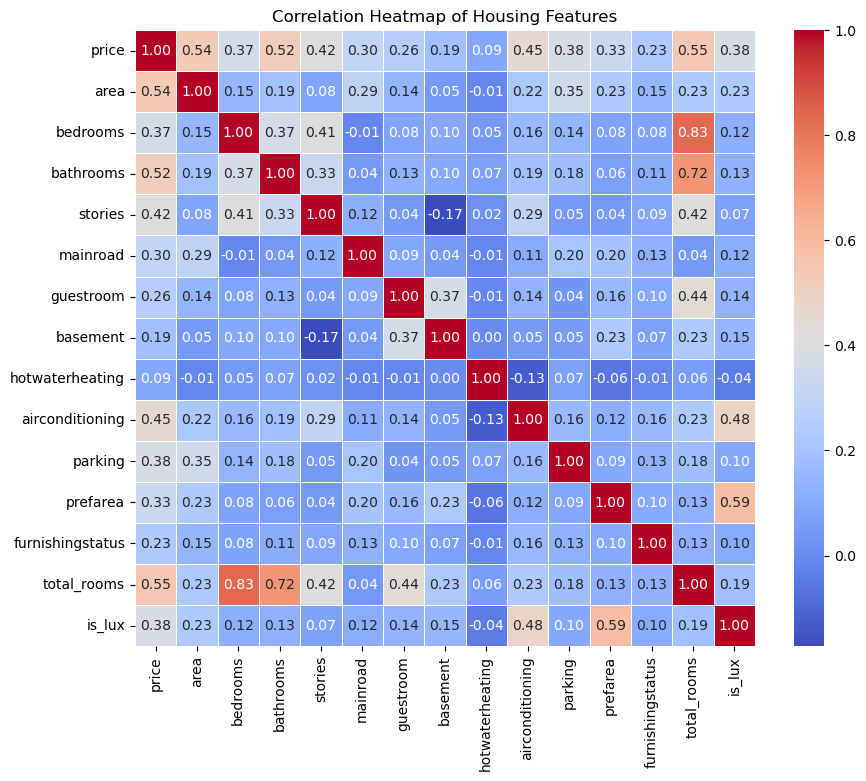

In [21]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Housing Features')
plt.show()

### Split Data

In [22]:
selected_features = ['area', 'bathrooms', 'stories', 'airconditioning', 'parking', 'prefarea', 'total_rooms']

x = df[selected_features]
y = df["price"]

x_train, x_test, y_train, y_test, = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [23]:
print("x_train size", x_train.shape[0])
print("x_test size", x_test.shape[0])
print("y_train size", y_train.shape[0])
print("y_test size", y_test.shape[0])

x_train size 436
x_test size 109
y_train size 436
y_test size 109


### Baseline Decision Tree Regression

In [24]:
pipeline_dt = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), x.columns)
        ]
    )),
    ("model_dt", DecisionTreeRegressor(random_state=42))
])

In [25]:
pipeline_dt.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                ('model_dt', DecisionTreeRegressor(random_state=42))])

In [26]:
y_pred_baseline = pipeline_dt.predict(x_test)

r2_dt_base = r2_score(y_test, y_pred_baseline)
mse_dt_base = mean_squared_error(y_test, y_pred_baseline)
mae_dt_base = mean_absolute_error(y_test, y_pred_baseline)
mape_dt_base = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("R2:", r2_dt_base)
print("MSE:", mse_dt_base)
print("MAE:", mae_dt_base)
print("MAPE:", mape_dt_base)

R2: 0.4308044737880714
MSE: 2877038771151.8857
MAE: 1258844.0366972478
MAPE: 0.28054473739182917


### Hypertuning Decision Tree Regressor

In [27]:
param_dt = {
    'model_dt__max_depth': [None, 5, 8, 12],
    'model_dt__min_samples_split': [2, 5, 10],
    'model_dt__min_samples_leaf': [1, 2, 4],
    'model_dt__criterion': ['squared_error', 'friedman_mse']
}

grid_dt = GridSearchCV(
    pipeline_dt, 
    param_grid = param_dt,
    cv=5, 
    scoring='r2')
grid_dt.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                                       ('model_dt',
                                        DecisionTreeRegressor(random_state=42))]),
             param_grid={'model_dt__criterion': ['squared_error',
                                                 'friedman_mse'],
                         'model_dt__max_depth': [None, 5, 8, 12],
                         'model_dt__min_samples_leaf': [1, 2, 4],
                         'model_dt__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [28]:
grid_dt.best_params_

{'model_dt__criterion': 'squared_error',
 'model_dt__max_depth': 5,
 'model_dt__min_samples_leaf': 4,
 'model_dt__min_samples_split': 10}

In [29]:
dt_tuned_model = grid_dt.best_estimator_

y_pred_tuned = dt_tuned_model.predict(x_test)

r2_dt_tuned = r2_score(y_test, y_pred_tuned)
mse_dt_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_dt_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_dt_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned)

print("R2:", r2_dt_tuned)
print("MSE:", mse_dt_tuned)
print("MAE:", mae_dt_tuned)
print("MAPE:", mape_dt_tuned)

R2: 0.5002046900543196
MSE: 2526250502921.5776
MAE: 1160703.9208046163
MAPE: 0.25201385189938785


### Random Forest Regressor Baseline

In [30]:
pipeline_rf = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), x.columns)
        ]
    )),
    ("model_rf", RandomForestRegressor(random_state=42))
])

In [31]:
pipeline_rf.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                ('model_rf', RandomForestRegressor(random_state=42))])

In [32]:
y_pred_baseline = pipeline_rf.predict(x_test)

r2_rf_base = r2_score(y_test, y_pred_baseline)
mse_rf_base = mean_squared_error(y_test, y_pred_baseline)
mae_rf_base = mean_absolute_error(y_test, y_pred_baseline)
mape_rf_base = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("R2:", r2_rf_base)
print("MSE:", mse_rf_base)
print("MAE:", mae_rf_base)
print("MAPE:", mape_rf_base)

R2: 0.5971663522810365
MSE: 2036150969992.831
MAE: 1037991.8833333334
MAPE: 0.22497885602732087


### Hypertuning Random Forest Regressor

In [33]:
param_rf = {
    'model_rf__n_estimators': [200, 500],
    'model_rf__max_depth': [5, 8, 10],
    'model_rf__min_samples_split': [5, 10],
    'model_rf__min_samples_leaf': [2, 4], 
    'model_rf__max_features': ['sqrt'],
    'model_rf__bootstrap': [True]
}

grid_rf = GridSearchCV(
    pipeline_rf, 
    param_grid = param_rf,
    cv=5, 
    scoring='r2')
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                                       ('model_rf',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'model_rf__bootstrap': [True],
                         'model_rf__max_depth': [5, 8, 10],
                         'model_rf__max_features': ['sqrt'],
                         'model_rf__min_samples_leaf': [2, 4],
                         'model_rf__min_samples_split': [5, 10],
                         'model_rf__n_estimators': [200, 500]},
             scoring='r2')

In [34]:
grid_rf.best_params_

{'model_rf__bootstrap': True,
 'model_rf__max_depth': 8,
 'model_rf__max_features': 'sqrt',
 'model_rf__min_samples_leaf': 2,
 'model_rf__min_samples_split': 5,
 'model_rf__n_estimators': 500}

In [35]:
rf_tuned_model = grid_rf.best_estimator_

y_pred_tuned = dt_tuned_model.predict(x_test)

r2_rf_tuned = r2_score(y_test, y_pred_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_rf_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_rf_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned)

print("R2:", r2_rf_tuned)
print("MSE:", mse_rf_tuned)
print("MAE:", mae_rf_tuned)
print("MAPE:", mape_rf_tuned)

R2: 0.5002046900543196
MSE: 2526250502921.5776
MAE: 1160703.9208046163
MAPE: 0.25201385189938785


### Gradient Boosting Regressor Baseline

In [36]:
pipeline_gb = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), x.columns)
        ]
    )),
    ("model_gb", GradientBoostingRegressor(random_state=42))
])

In [37]:
pipeline_gb.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                ('model_gb', GradientBoostingRegressor(random_state=42))])

In [38]:
y_pred_baseline = pipeline_gb.predict(x_test)

r2_gb_base = r2_score(y_test, y_pred_baseline)
mse_gb_base = mean_squared_error(y_test, y_pred_baseline)
mae_gb_base = mean_absolute_error(y_test, y_pred_baseline)
mape_gb_base = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("R2:", r2_gb_base)
print("MSE:", mse_gb_base)
print("MAE:", mae_gb_base)
print("MAPE:", mape_gb_base)

R2: 0.5986021177533889
MSE: 2028893792555.5286
MAE: 1026091.6436283181
MAPE: 0.219936726316538


### Hypertuning Gradient Boosting Regressor

In [59]:
param_gb = {
    'model_gb__n_estimators': [100, 500],
    'model_gb__learning_rate': [0.05, 0.1],
    'model_gb__max_depth': [3, 4],
    'model_gb__subsample': [0.8],
    'model_gb__max_features': ['sqrt', None]
}

grid_gb = GridSearchCV(
    pipeline_gb, 
    param_grid = param_gb,
    cv=5, 
    scoring='r2')
grid_gb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                                       ('model_gb',
                                        GradientBoostingRegressor(random_state=42))]),
             param_grid={'model_gb__learning_rate': [0.05, 0.1],
                         'model_gb__max_depth': [3, 4],
                         'model_gb__max_features': ['sqrt', None],
                         'model_gb__n_estimators': [100, 500],
                         'model_gb__subsample': [0.8]},
             scoring='r2')

In [60]:
grid_gb.best_params_

{'model_gb__learning_rate': 0.05,
 'model_gb__max_depth': 3,
 'model_gb__max_features': 'sqrt',
 'model_gb__n_estimators': 100,
 'model_gb__subsample': 0.8}

In [61]:
gb_tuned_model = grid_gb.best_estimator_

y_pred_tuned = gb_tuned_model.predict(x_test)

r2_gb_tuned = r2_score(y_test, y_pred_tuned)
mse_gb_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_gb_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_gb_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned)

print("R2:", r2_gb_tuned)
print("MSE:", mse_gb_tuned)
print("MAE:", mae_gb_tuned)
print("MAPE:", mape_gb_tuned)

R2: 0.6403568411093254
MSE: 1817841610235.6294
MAE: 990084.5307366048
MAPE: 0.21874054503738105


### XGB Regressor Baseline

In [63]:
pipeline_xgb = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), x.columns)
        ]
    )),
    ("model_xgb", XGBRegressor(random_state=42))
])

In [64]:
pipeline_xgb.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                ('model_xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [65]:
y_pred_baseline = pipeline_xgb.predict(x_test)

r2_xgb_base = r2_score(y_test, y_pred_baseline)
mse_xgb_base = mean_squared_error(y_test, y_pred_baseline)
mae_xgb_base = mean_absolute_error(y_test, y_pred_baseline)
mape_xgb_base = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("R2:", r2_xgb_base)
print("MSE:", mse_xgb_base)
print("MAE:", mae_xgb_base)
print("MAPE:", mape_xgb_base)

R2: 0.5272286614002999
MSE: 2389655941417.7065
MAE: 1136346.5068807339
MAPE: 0.24354959688221955


### Hypertuning XGB

In [45]:
param_xgb = {
    'model_xgb__n_estimators': [100, 500],
    'model_xgb__learning_rate': [0.01, 0.05, 0.1],
    'model_xgb__max_depth': [3, 5, 7],
    'model_xgb__subsample': [0.8, 0.9],
    'model_xgb__colsample_bytree': [0.8, 0.9],
    'model_xgb__gamma': [0, 0.1, 0.2],
    'model_xgb__reg_lambda': [1, 5, 10]
}

grid_xgb = GridSearchCV(
    pipeline_xgb, 
    param_grid = param_xgb,
    cv=5, 
    scoring='r2')
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea', 'total_rooms'],
      dtype='object'))])),
                                       ('model_xgb',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_b...
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             param_grid={'model_xgb__colsample_bytree': [0.8, 0.9],
                         'model_xgb__gamma': [0, 0.1, 0.2],
                         'model_xgb__learning_rate': [0.01, 0.05, 0.1],
                         'model_xgb__max_depth': [3, 5, 7],
                         'model_xgb__n_estimators': [100, 500],
                         'model_xgb__reg_lambda': [1, 5, 10],
                         'model_xgb__subsample': [0.8, 0.9]},
             scoring='r2')

In [46]:
grid_xgb.best_params_

{'model_xgb__colsample_bytree': 0.8,
 'model_xgb__gamma': 0,
 'model_xgb__learning_rate': 0.1,
 'model_xgb__max_depth': 3,
 'model_xgb__n_estimators': 100,
 'model_xgb__reg_lambda': 5,
 'model_xgb__subsample': 0.9}

In [47]:
xgb_tuned_model = grid_xgb.best_estimator_

y_pred_tuned = xgb_tuned_model.predict(x_test)

r2_xgb_tuned = r2_score(y_test, y_pred_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_tuned)
mape_xgb_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned)

print("R2:", r2_xgb_tuned)
print("MSE:", mse_xgb_tuned)
print("MAE:", mae_xgb_tuned)
print("MAPE:", mape_xgb_tuned)

R2: 0.6274043895691036
MSE: 1883310686408.2512
MAE: 987339.9770642202
MAPE: 0.21472038265369178


### Comparing The Models

In [48]:
print("--DT Baseline--")
print("R2:", r2_dt_base)
print("MSE:", mse_dt_base)
print("MAE:", mae_dt_base)
print("MAPE:", mape_dt_base)
print("\n")

print("--Tuned DT--")
print("R2:", r2_dt_tuned)
print("MSE:", mse_dt_tuned)
print("MAE:", mae_dt_tuned)
print("MAPE:", mape_dt_tuned)
print("\n")

print("--RF Baseline--")
print("R2:", r2_rf_base)
print("MSE:", mse_rf_base)
print("MAE:", mae_rf_base)
print("MAPE:", mape_rf_base)
print("\n")

print("--Tuned RF--")
print("R2:", r2_rf_tuned)
print("MSE:", mse_rf_tuned)
print("MAE:", mae_rf_tuned)
print("MAPE:", mape_rf_tuned)
print("\n")

print("--GBM Baseline--")
print("R2:", r2_gb_base)
print("MSE:", mse_gb_base)
print("MAE:", mae_gb_base)
print("MAPE:", mape_gb_base)
print("\n")

print("--Tuned GBM--")
print("R2:", r2_gb_tuned)
print("MSE:", mse_gb_tuned)
print("MAE:", mae_gb_tuned)
print("MAPE:", mape_gb_tuned)
print("\n")

print("--XGB Baseline--")
print("R2:", r2_xgb_base)
print("MSE:", mse_xgb_base)
print("MAE:", mae_xgb_base)
print("MAPE:", mape_xgb_base)
print("\n")

print("--Tuned XGB--")
print("R2:", r2_xgb_tuned)
print("MSE:", mse_xgb_tuned)
print("MAE:", mae_xgb_tuned)
print("MAPE:", mape_xgb_tuned)

--DT Baseline--
R2: 0.4308044737880714
MSE: 2877038771151.8857
MAE: 1258844.0366972478
MAPE: 0.28054473739182917


--Tuned DT--
R2: 0.5002046900543196
MSE: 2526250502921.5776
MAE: 1160703.9208046163
MAPE: 0.25201385189938785


--RF Baseline--
R2: 0.5971663522810365
MSE: 2036150969992.831
MAE: 1037991.8833333334
MAPE: 0.22497885602732087


--Tuned RF--
R2: 0.5002046900543196
MSE: 2526250502921.5776
MAE: 1160703.9208046163
MAPE: 0.25201385189938785


--GBM Baseline--
R2: 0.5986021177533889
MSE: 2028893792555.5286
MAE: 1026091.6436283181
MAPE: 0.219936726316538


--Tuned GBM--
R2: 0.6403568411093254
MSE: 1817841610235.6294
MAE: 990084.5307366048
MAPE: 0.21874054503738105


--XGB Baseline--
R2: 0.5272286614002999
MSE: 2389655941417.7065
MAE: 1136346.5068807339
MAPE: 0.24354959688221955


--Tuned XGB--
R2: 0.6274043895691036
MSE: 1883310686408.2512
MAE: 987339.9770642202
MAPE: 0.21472038265369178


###### Ranking
###### 1. Tuned GBM
###### 2. Tuned XGB
###### 3. GBM Baseline
###### 4. RF Baseline

### Learning Curve (Top 4 Model)

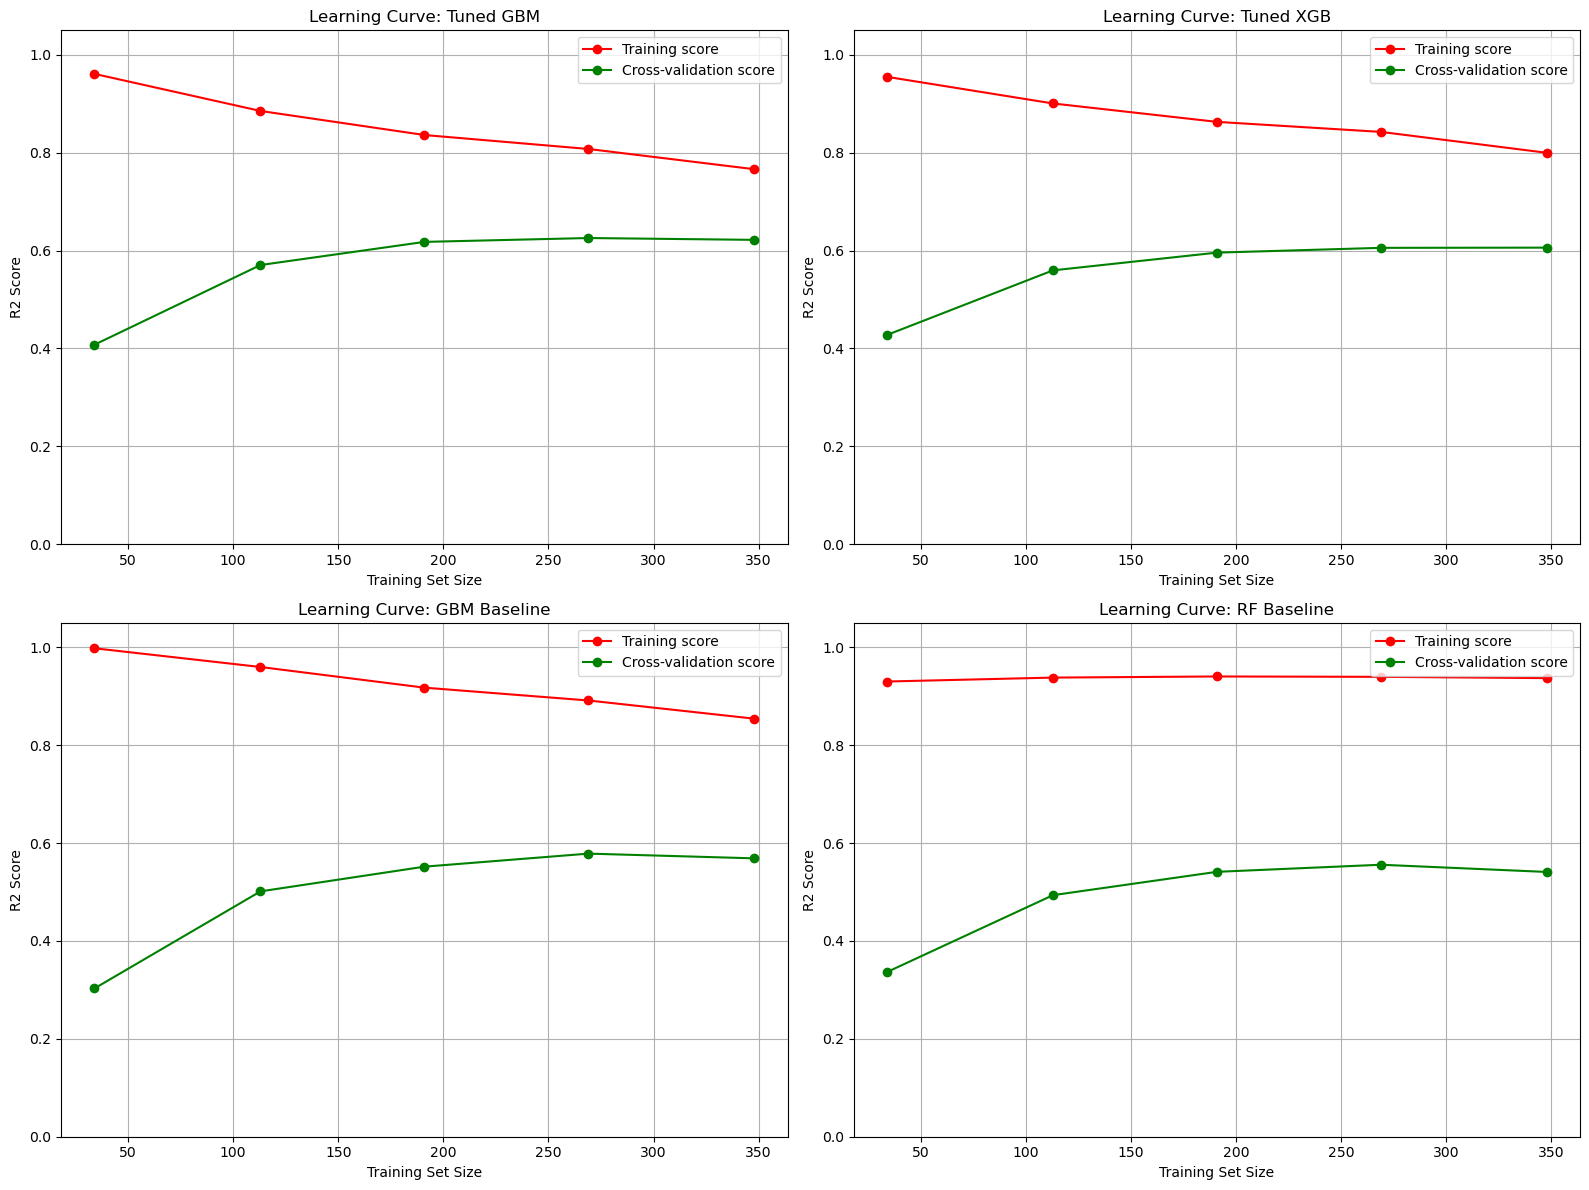

In [66]:
#Tuned GBM
tuned_GBM = gb_tuned_model

#Tuned XGB
tuned_XGB = xgb_tuned_model

#Baseline GBM
baseline_GBM = pipeline_gb

#Baseline RF
baseline_RF = pipeline_rf

train_sizes = np.linspace(0.1, 1.0, 5)

def plot_learning_curve(model, X, y, ax, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5, scoring="r2", n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation score")
    ax.set_title(title)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("R2 Score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="best")
    ax.grid(True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes.ravel()

plot_learning_curve(tuned_GBM, x_train, y_train, ax[0], "Learning Curve: Tuned GBM")

plot_learning_curve(tuned_XGB, x_train, y_train, ax[1], "Learning Curve: Tuned XGB")

plot_learning_curve(baseline_GBM, x_train, y_train, ax[2], "Learning Curve: GBM Baseline")

plot_learning_curve(baseline_RF, x_train, y_train, ax[3], "Learning Curve: RF Baseline")

plt.tight_layout()
plt.show()

###### The model has reached its optimal performance at an $R^2$ score of 64% because the current dataset contains too few and relatively weak features to explain higher price variations. This is clearly proven by the learning curves, which show that both the training and validation lines become nearly flat as the training set size increases from 200 to 300 samples. This horizontal trend indicates that the model has already learned almost everything possible from the available data, reaching a point of saturation where adding more observations or tuning parameters further will not significantly improve accuracy without new, more descriptive information.

### Save Model

In [67]:
import joblib

joblib.dump(gb_tuned_model, 'housing_price(GBM_tuned).pkl')

print("The model has been successfully saved as: housing_price(GBM_tuned).pkl")

The model has been successfully saved as: housing_price(GBM_tuned).pkl
